# Vocal Onset Detection — Self-Contained Demo

**Final project for Music Information Retrieval.**

## Research question

> Across **solo vocals** (vocadito) and **polyphonic choir vocals**
> (Dagstuhl ChoirSet), how do three classical onset detectors —
> librosa Spectral Flux, librosa SuperFlux, and madmom's CNN-based
> detector — compare in terms of F-measure, and what kinds of errors
> dominate?

## Outline
1. Setup
2. Datasets — peek at one track from each
3. Three onset detectors — run on a sample track
4. Quantitative evaluation — F / P / R across the whole corpus
5. Qualitative error analysis — spectrogram overlays + error taxonomy
6. Discussion


## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('..'))   # so we can import the src/ package

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display

from src.data       import load_vocadito, load_dagstuhl
from src.detectors  import DETECTORS
from src.evaluate   import evaluate_track, evaluate_all, summary_table
from src.viz        import (plot_onsets_on_spectrogram,
                            plot_three_methods, categorize_errors)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print('Setup OK')

Setup OK


## 2. Datasets

We use two complementary datasets, both loaded via [mirdata](https://mirdata.readthedocs.io/):

| Dataset | Type | # Tracks | Annotation source |
|---|---|---|---|
| **vocadito** | solo vocals, multi-language | 40 | manual notes (annotator A1) |
| **Dagstuhl ChoirSet** | polyphonic SATB choir, mixed-room mic | 20 | per-multitrack score notes (deduped, 30 ms) |


In [2]:
vocadito_tracks = load_vocadito()
choir_tracks    = load_dagstuhl()

print(f'vocadito         : {len(vocadito_tracks)} tracks')
print(f'dagstuhl_choirset: {len(choir_tracks)} tracks')

# A glance at the metadata
pd.DataFrame([t.metadata | {'track_id': t.track_id, 'n_onsets': len(t.onsets)}
              for t in vocadito_tracks[:5]])

vocadito         : 40 tracks
dagstuhl_choirset: 20 tracks


,language,singer_id,annotator,n_notes,track_id,n_onsets
0,Tagalog,S1,a1,59,1,59
1,English,S7,a1,35,10,35
2,English,S8,a1,37,11,37
3,English,S9,a1,27,12,27
4,French,S10,a1,74,13,74


In [3]:
# Listen + look at one solo example
from IPython.display import Audio, display

tr = vocadito_tracks[0]
audio, sr = tr.load_audio()

print(tr)
print(f'Language: {tr.metadata["language"]}, Singer: {tr.metadata["singer_id"]}')
print(f'Duration: {len(audio)/sr:.1f} s,   Ground-truth onsets: {len(tr.onsets)}')
display(Audio(audio, rate=sr))

Track(dataset='vocadito', track_id='1', n_onsets=59)
Language: Tagalog, Singer: S1
Duration: 33.2 s,   Ground-truth onsets: 59


## 3. Three onset detectors

All three follow the same two-stage pattern:

```
audio  ─► onset-strength curve  ─► peak picking  ─► onset times (sec)
```

* **Spectral Flux** — sum of positive frame-to-frame log-magnitude differences (`librosa.onset.onset_strength`).
* **SuperFlux** — same, but with a 3-bin maximum filter on the magnitude spectrogram to suppress vibrato (Böck & Widmer, DAFx 2013).
* **madmom CNN** — a pre-trained CNN that outputs a per-frame onset probability at 100 fps (Schlüter & Böck, 2014).


In [4]:
estimates = {name: fn(audio, sr) for name, fn in DETECTORS.items()}

for name, est in estimates.items():
    m = evaluate_track(tr.onsets, est, tolerance=0.05)
    print(f'{name:15s}  '
          f'P={m["precision"]:.3f}  R={m["recall"]:.3f}  F={m["f_measure"]:.3f}  '
          f'(est={m["n_est"]}, ref={m["n_ref"]})')

spectral_flux    P=0.487  R=0.661  F=0.561  (est=80, ref=59)
superflux        P=0.500  R=0.661  F=0.569  (est=78, ref=59)
madmom_cnn       P=0.677  R=0.712  F=0.694  (est=62, ref=59)


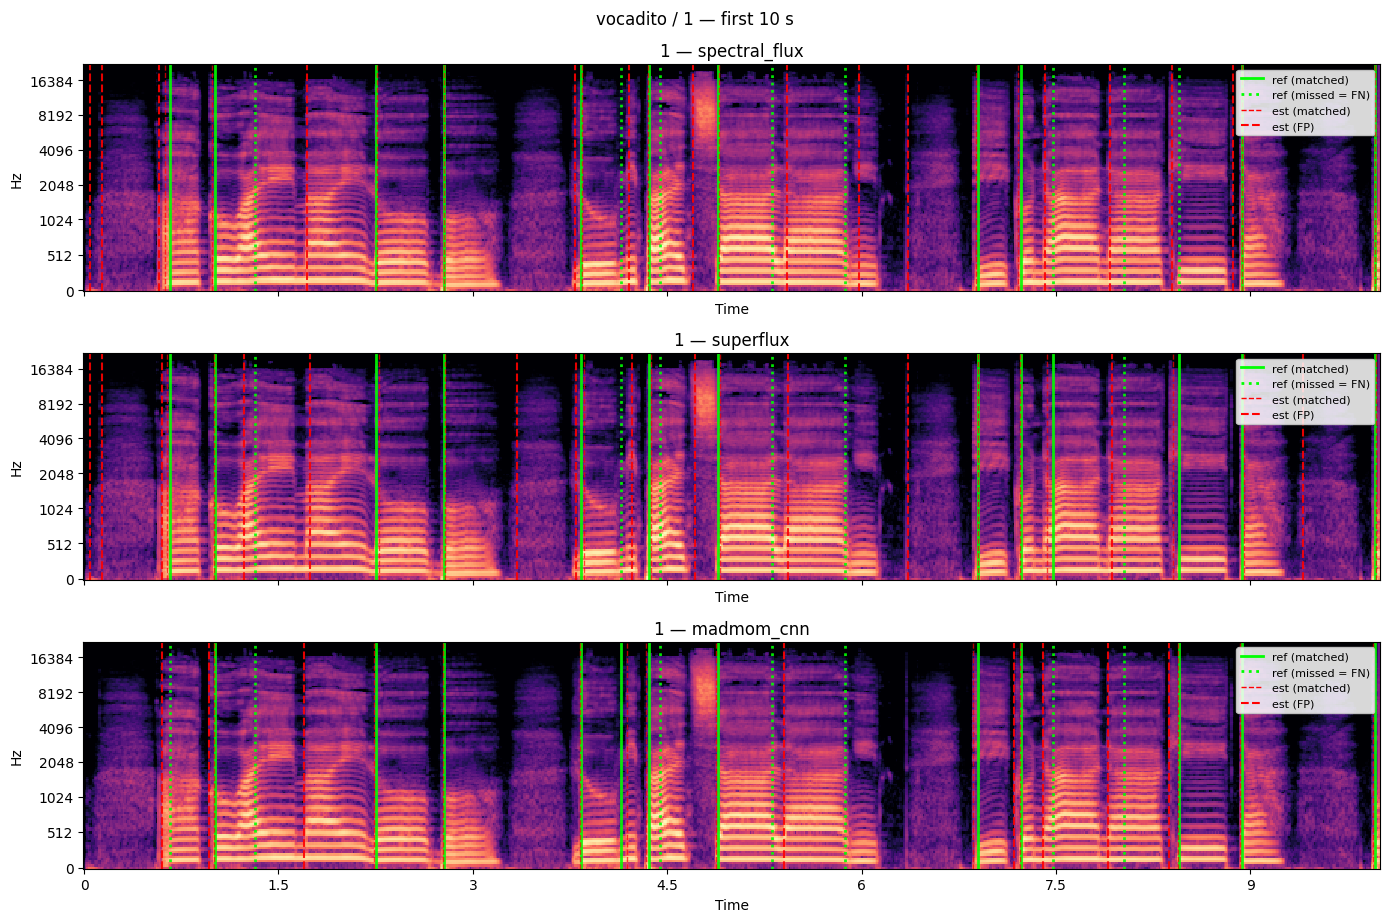

In [5]:
# Look at the first ~10 seconds where the singer enters
fig = plot_three_methods(tr, audio, sr, estimates,
                         tolerance=0.05, t_start=0.0, t_end=10.0,
                         figsize=(14, 9))
fig.suptitle(f'{tr.dataset} / {tr.track_id} — first 10 s', y=1.02)
plt.show()

**What to look for**

* **Solid green** = ground-truth onset that *was* detected within ±50 ms (TP).
* **Dotted green** = ground-truth onset *missed* (FN).
* **Dashed red** = detector output. Thick red = **false positive**.

Already on this single track you can see both librosa methods place a couple of false alarms in the first ~0.4 s before the singer enters (mic noise / breath), while madmom CNN does not.

## 4. Quantitative evaluation

We ran every detector on every track once and saved the per-track metrics to
`results/raw_metrics.csv`. Re-running takes ~1 minute (60 tracks × 3 detectors)
— change the cell below if you want to re-evaluate.

The standard MIREX evaluation is the **F-measure with a ±50 ms tolerance**
(`mir_eval.onset.f_measure`).

In [6]:
RESULTS_CSV = '../results/raw_metrics.csv'

if os.path.exists(RESULTS_CSV):
    print('Loading cached results from', RESULTS_CSV)
    df = pd.read_csv(RESULTS_CSV)
else:
    print('Running full evaluation (1-2 minutes)...')
    df = evaluate_all(vocadito_tracks + choir_tracks, DETECTORS, tolerance=0.05,
                      verbose=False)
    df.to_csv(RESULTS_CSV, index=False)

print(f'{len(df)} rows = {df["track_id"].nunique()} tracks × {df["detector"].nunique()} detectors')
df.head()

Loading cached results from ../results/raw_metrics.csv
180 rows = 60 tracks × 3 detectors


,dataset,track_id,detector,precision,recall,f_measure,n_ref,n_est,meta_language,meta_singer_id,meta_annotator,meta_n_notes,meta_mic,meta_n_singers,meta_n_score_events,meta_n_unique_onsets,meta_piece,meta_ensemble
0,vocadito,1,spectral_flux,0.487500,0.661017,0.561151,59,80,Tagalog,S1,a1,59.0,NaN,NaN,NaN,NaN,NaN,NaN
1,vocadito,1,superflux,0.500000,0.661017,0.569343,59,78,Tagalog,S1,a1,59.0,NaN,NaN,NaN,NaN,NaN,NaN
2,vocadito,1,madmom_cnn,0.677419,0.711864,0.694215,59,62,Tagalog,S1,a1,59.0,NaN,NaN,NaN,NaN,NaN,NaN
3,vocadito,10,spectral_flux,0.583333,0.600000,0.591549,35,36,English,S7,a1,35.0,NaN,NaN,NaN,NaN,NaN,NaN
4,vocadito,10,superflux,0.656250,0.600000,0.626866,35,32,English,S7,a1,35.0,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
summary_table(df)

precision        recall        f_measure  \
                                     mean    std   mean    std      mean   
dataset           detector                                                 
dagstuhl_choirset madmom_cnn        0.461  0.100  0.235  0.078     0.306   
                  spectral_flux     0.258  0.062  0.489  0.113     0.328   
                  superflux         0.328  0.058  0.359  0.098     0.337   
vocadito          madmom_cnn        0.657  0.092  0.678  0.108     0.662   
                  spectral_flux     0.527  0.071  0.628  0.101     0.568   
                  superflux         0.543  0.079  0.577  0.133     0.552   

                                        
                                   std  
dataset           detector              
dagstuhl_choirset madmom_cnn     0.083  
                  spectral_flux  0.057  
                  superflux      0.066  
vocadito          madmom_cnn     0.087  
                  spectral_flux  0.067  
                  superflux      0.094

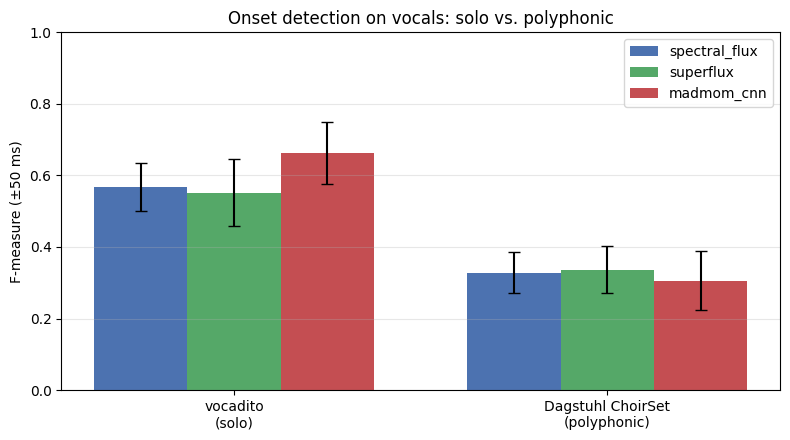

In [8]:
# Bar chart: F-measure mean ± std, grouped by dataset
fig, ax = plt.subplots(figsize=(8, 4.5))

datasets  = ['vocadito', 'dagstuhl_choirset']
detectors = ['spectral_flux', 'superflux', 'madmom_cnn']
colors    = ['#4C72B0', '#55A868', '#C44E52']
x         = np.arange(len(datasets))
w         = 0.25

for i, det in enumerate(detectors):
    sub  = df[df['detector'] == det]
    means = [sub[sub['dataset'] == ds]['f_measure'].mean() for ds in datasets]
    stds  = [sub[sub['dataset'] == ds]['f_measure'].std()  for ds in datasets]
    ax.bar(x + i * w - w, means, w, yerr=stds, capsize=4,
           label=det, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(['vocadito\n(solo)', 'Dagstuhl ChoirSet\n(polyphonic)'])
ax.set_ylabel('F-measure (±50 ms)')
ax.set_title('Onset detection on vocals: solo vs. polyphonic')
ax.set_ylim(0, 1)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig('../results/f_measure_bar.png', dpi=150)
plt.show()

### Key findings

1. **Polyphonic choir is much harder.** Best F drops from **~0.66 (solo, CNN)** to **~0.34 (polyphonic, SuperFlux)** — a halving of performance.
2. **The winner flips between datasets.** madmom CNN is the best detector on solo vocals, but the *worst* on choir mixes.
3. **CNN's failure mode is low recall.** On Dagstuhl, the CNN has the highest precision (0.46) but the lowest recall (0.24) — i.e. it misses most onsets but rarely fires spuriously. SuperFlux's vibrato suppression gives it a more balanced P/R trade-off, which is why it wins on F.

## 5. Qualitative error analysis

Where exactly do the methods fail? We classify each FP and FN with the heuristics in `src.viz.categorize_errors`:

| Label | Definition |
|---|---|
| `fp_double` | False positive that lies within 120 ms of an estimate that *did* match a reference → likely a **double trigger** of the same true onset. |
| `fp_isolated` | False positive with no estimate near → genuine spurious detection (vibrato, breath, …). |
| `fn_shifted` | Missed onset whose nearest estimate lies within 100 ms (i.e. the algorithm fired *near* but outside the 50 ms window). |
| `fn_hardmiss` | Missed onset with no nearby estimate at all → algorithm completely silent here (typical for legato vowel transitions). |


In [9]:
rows = []
for tracks, dataset_name in [(vocadito_tracks, 'vocadito'),
                             (choir_tracks,    'dagstuhl_choirset')]:
    for tr in tracks:
        audio, sr = tr.load_audio()
        for det_name, fn in DETECTORS.items():
            est = fn(audio, sr)
            cats = categorize_errors(tr.onsets, est, tol=0.05)
            rows.append({'dataset': dataset_name, 'detector': det_name,
                         'track_id': tr.track_id, **cats})
err = pd.DataFrame(rows)
err.to_csv('../results/error_taxonomy.csv', index=False)
err.head()

,dataset,detector,track_id,tp,fp_double,fp_isolated,fn_shifted,fn_hardmiss
0,vocadito,spectral_flux,1,39,5,36,8,12
1,vocadito,superflux,1,39,4,35,8,12
2,vocadito,madmom_cnn,1,42,5,15,6,11
3,vocadito,spectral_flux,10,21,3,12,6,8
4,vocadito,superflux,10,21,1,10,6,8


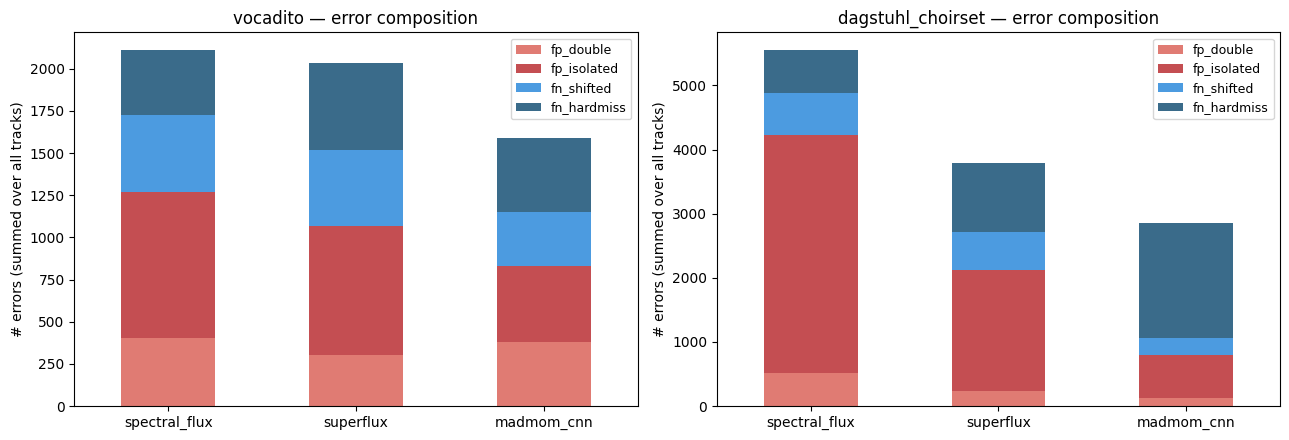

In [10]:
# Stacked bars: composition of errors
agg = err.groupby(['dataset', 'detector'])[
    ['fp_double', 'fp_isolated', 'fn_shifted', 'fn_hardmiss']].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, ds in zip(axes, ['vocadito', 'dagstuhl_choirset']):
    sub = agg.loc[ds].reindex(['spectral_flux', 'superflux', 'madmom_cnn'])
    sub.plot(kind='bar', stacked=True, ax=ax,
             color=['#E07B73', '#C44E52', '#4C9BE0', '#3A6B8A'])
    ax.set_title(f'{ds} — error composition')
    ax.set_ylabel('# errors (summed over all tracks)')
    ax.set_xlabel('')
    ax.legend(loc='upper right', fontsize=9)
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
fig.savefig('../results/error_composition.png', dpi=150)
plt.show()

### Case study: why does CNN fail on choir mixes?

Pick the Dagstuhl track where CNN's recall is lowest and visualize what's happening.

Worst CNN-recall Dagstuhl track: DCS_TP_FullChoir_Take02
  spectral_flux   F=0.252 P=0.194 R=0.360
  superflux       F=0.296 P=0.333 R=0.267
  madmom_cnn      F=0.163 P=0.348 R=0.107


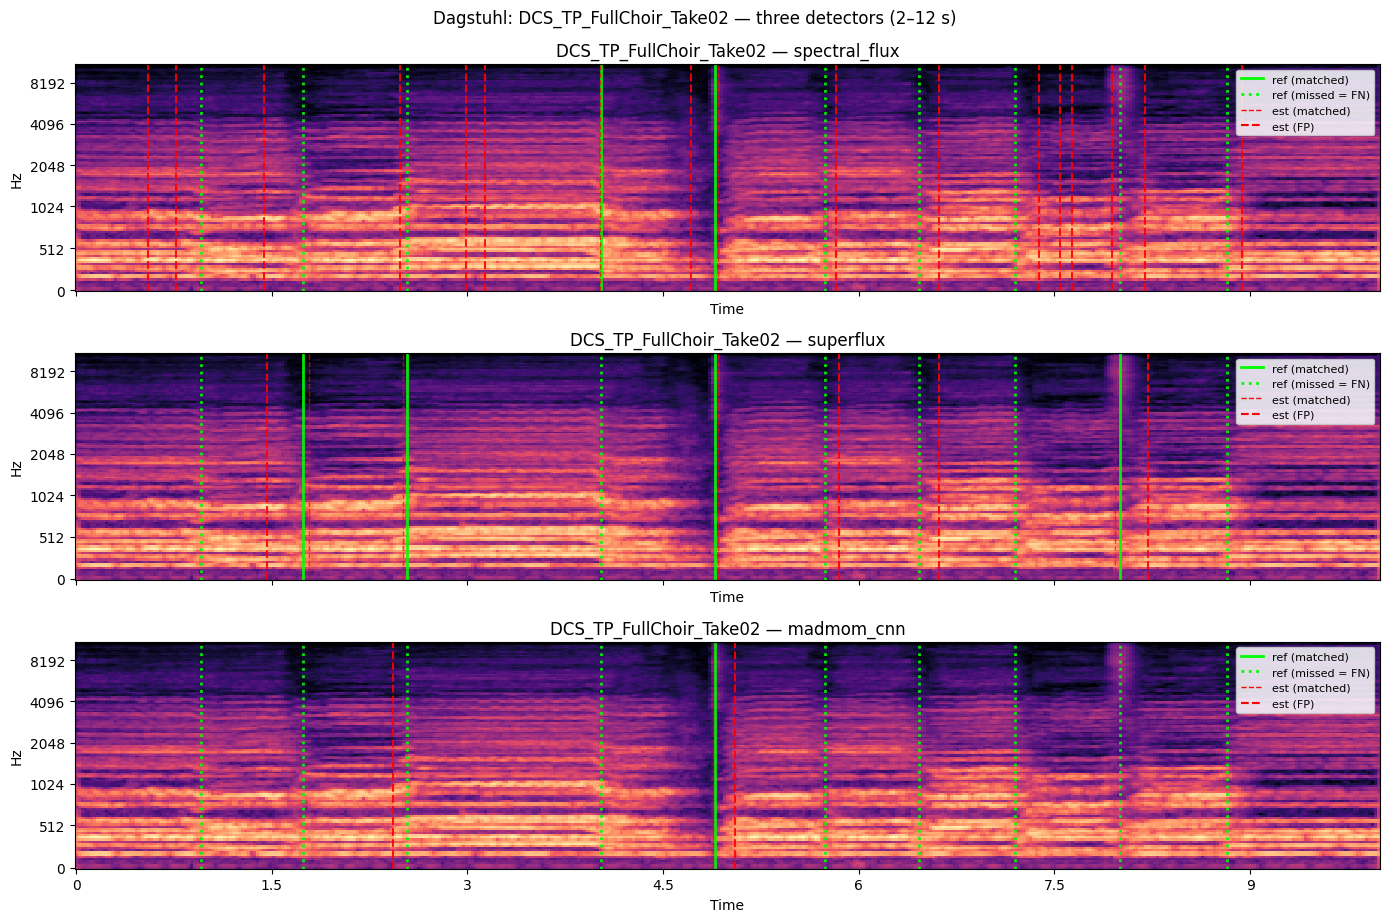

In [11]:
# find worst CNN-recall Dagstuhl track
cnn_dcs = df[(df['dataset'] == 'dagstuhl_choirset') & (df['detector'] == 'madmom_cnn')]
worst_id = cnn_dcs.sort_values('recall').iloc[0]['track_id']
print('Worst CNN-recall Dagstuhl track:', worst_id)

tr = next(t for t in choir_tracks if t.track_id == worst_id)
audio, sr = tr.load_audio()
estimates = {name: fn(audio, sr) for name, fn in DETECTORS.items()}

for name, est in estimates.items():
    m = evaluate_track(tr.onsets, est, tolerance=0.05)
    print(f'  {name:15s} F={m["f_measure"]:.3f} P={m["precision"]:.3f} R={m["recall"]:.3f}')

fig = plot_three_methods(tr, audio, sr, estimates,
                         tolerance=0.05, t_start=2.0, t_end=12.0,
                         figsize=(14, 9))
fig.suptitle(f'Dagstuhl: {tr.track_id} — three detectors (2–12 s)', y=1.02)
plt.show()

**Observation.** The mel spectrogram shows long *sustained* harmonic stacks with very smooth voice-leading: there are no sharp percussive attacks. The CNN — trained largely on instrumental music with clear transients — outputs a low onset probability throughout, producing few estimates. SuperFlux's vibrato-robust spectral flux still picks up the small spectral re-arrangements at chord changes, so it wins despite having lower precision than the CNN.

## 6. Discussion

### Answers to the research question

* **Solo vocals** (vocadito): madmom CNN is best (F=0.66). Its main remaining errors are *isolated false positives* on breaths and consonant onsets.
* **Polyphonic choir** (Dagstuhl): SuperFlux is best (F=0.34). The CNN trades recall for precision and ends up *under-detecting*; plain spectral flux is the opposite (over-detecting).

### Limitations

* Only one piece (`Locus Iste`) in the polyphonic set. Whether the ranking holds on more diverse choral repertoire is open.
* Dagstuhl notes are *score* events, not *acoustic* onsets — soft consonants that fall before the score onset will count as FN even if perceptually correct. A study using laryngograph-derived acoustic onsets would be a fairer test.
* Hyperparameters of librosa's peak picker were tuned coarsely; a per-dataset grid search could change the absolute numbers (though probably not the ranking).

### Future work

* Run on demucs-separated vocals from the original mixes — does extracting the vocals first close the solo↔polyphonic gap?
* Re-train / fine-tune the CNN on choir data using Dagstuhl's per-singer HSM tracks as supervision.